# **CardioIA — Artificial Intelligence in Health Time Series**

This notebook presents an experimental comparison between a traditional machine learning model and a simple neuromorphic model applied to synthetic health time-series data.

The dataset represents simulated readings from the CardioIA project, including body temperature, heart rate, movement level, movement detection, and emergency button activation. The goal is to classify each time window into one of four risk levels: normal, medium, high, or critical.

Two approaches are evaluated:

1. Logistic Regression, used as a traditional and interpretable classification baseline.
2. Leaky Integrate-and-Fire (LIF), used as a simple neuromorphic model inspired by biological neurons.

The results are compared using accuracy, precision, recall, F1-score, confusion matrices, and visual analysis.

In [1]:
# =============================================================================
# CardioIA — Artificial Intelligence in Health Time Series
# AUTHOR: Raphael da Silva  RM: 561452
# GROUP: São Paulo e Interior
# =============================================================================

# ============================================================
# 1. Google Drive Mount
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

# ============================================================
# 2. Imports
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# ============================================================
# 3. Google Drive Project Paths
# ============================================================

# Main project folder inside Google Drive.
# If your folder is inside another directory, change only this variable.
PROJECT_ROOT = Path("/content/drive/MyDrive/go_beyond2")

DATA_ROOT = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_ROOT / "raw" / "cardioia_dataset"
RAW_ALL_DIR = RAW_DATA_DIR / "All"

PROCESSED_DIR = DATA_ROOT / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

RAW_DATASET_PATH = RAW_ALL_DIR / "cardioia_synthetic_300_records.csv"

for directory in [
    PROJECT_ROOT,
    DATA_ROOT,
    RAW_DATA_DIR,
    RAW_ALL_DIR,
    PROCESSED_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dataset path:", RAW_DATASET_PATH)
print("Processed directory:", PROCESSED_DIR)
print("Figures directory:", FIGURES_DIR)
print("Metrics directory:", METRICS_DIR)
print("Predictions directory:", PREDICTIONS_DIR)

Mounted at /content/drive
Project root: /content/drive/MyDrive/go_beyond2
Raw dataset path: /content/drive/MyDrive/go_beyond2/data/raw/cardioia_dataset/All/cardioia_synthetic_300_records.csv
Processed directory: /content/drive/MyDrive/go_beyond2/data/processed
Figures directory: /content/drive/MyDrive/go_beyond2/outputs/figures
Metrics directory: /content/drive/MyDrive/go_beyond2/outputs/metrics
Predictions directory: /content/drive/MyDrive/go_beyond2/outputs/predictions


# **Dataset Description**

The dataset used in this notebook was synthetically generated based on the CardioIA monitoring scenario. It simulates data collected by a wearable health device, such as a smartwatch, using the following variables:

| Variable | Description |
|---|---|
| timestamp | Date and time of the simulated reading |
| temperature_c | Body or environmental temperature in Celsius |
| heart_rate_bpm | Simulated heart rate in beats per minute |
| movement_level | Numerical movement intensity from 0 to 1 |
| movement_detected | Boolean value indicating whether movement was detected |
| emergency_button_pressed | Boolean value indicating whether the emergency button was pressed |
| risk_level | Textual risk class |
| risk_label | Numerical class label |

The risk classes are organized as follows:

| Risk Level | Label | General Meaning |
|---|---:|---|
| normal | 0 | Stable physiological condition |
| medium | 1 | Moderate change in vital signs |
| high | 2 | Relevant abnormal condition |
| critical | 3 | Critical event, usually associated with emergency activation |

Since the data is synthetic, it should not be interpreted as clinical evidence. It is used only for academic experimentation and model comparison.

In [2]:
# ============================================================
# 4. Dataset Loading
# ============================================================

def normalize_column_names(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes dataframe column names to snake_case.
    """
    dataframe = dataframe.copy()

    dataframe.columns = (
        dataframe.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    return dataframe


def load_dataset() -> pd.DataFrame:
    """
    Loads the main dataset from Google Drive.

    Expected main file:
    /content/drive/MyDrive/go_beyond2/data/raw/cardioia_dataset/All/cardioia_synthetic_300_records.csv

    If the main file is not found, the function tries to combine CSV files
    from the class folders: Normal, Medium, High, and Critical.
    """

    if RAW_DATASET_PATH.exists():
        dataframe = pd.read_csv(RAW_DATASET_PATH)
        print("Main dataset loaded successfully from Google Drive.")
        return normalize_column_names(dataframe)

    class_folders = {
        "normal": RAW_DATA_DIR / "Normal",
        "medium": RAW_DATA_DIR / "Medium",
        "high": RAW_DATA_DIR / "High",
        "critical": RAW_DATA_DIR / "Critical"
    }

    frames = []

    for class_name, folder_path in class_folders.items():
        if not folder_path.exists():
            continue

        csv_files = list(folder_path.glob("*.csv"))

        for csv_file in csv_files:
            temp_df = pd.read_csv(csv_file)
            temp_df = normalize_column_names(temp_df)

            if "risk_level" not in temp_df.columns:
                temp_df["risk_level"] = class_name

            frames.append(temp_df)

    if len(frames) == 0:
        raise FileNotFoundError(
            "Dataset not found in Google Drive. Expected file:\n"
            f"{RAW_DATASET_PATH}\n\n"
            "Alternative: place CSV files inside the class folders:\n"
            "Normal, Medium, High, and Critical."
        )

    dataframe = pd.concat(frames, ignore_index=True)
    print("Dataset loaded from class folders in Google Drive.")

    return normalize_column_names(dataframe)


raw_df = load_dataset()

print("Dataset shape:", raw_df.shape)
display(raw_df.head())

Main dataset loaded successfully from Google Drive.
Dataset shape: (300, 8)


,timestamp,temperature_c,heart_rate_bpm,movement_level,movement_detected,emergency_button_pressed,risk_level,risk_label
0,2026-04-27T08:00:00,36.77,61,0.90,True,False,normal,0
1,2026-04-27T08:00:30,36.12,94,0.63,True,False,normal,0
2,2026-04-27T08:01:00,36.26,92,0.84,True,False,normal,0
3,2026-04-27T08:01:30,36.84,86,0.69,True,False,normal,0
4,2026-04-27T08:02:00,36.01,70,0.88,True,False,normal,0


# **Data Preprocessing**

Before training the models, the dataset must be cleaned and standardized. This step is important because machine learning models require consistent numerical and categorical data.

The preprocessing stage includes:

| Step | Purpose |
|---|---|
| Timestamp conversion | Ensures that the temporal order can be correctly interpreted |
| Boolean conversion | Converts text values such as "true" and "false" into Boolean values |
| Numerical conversion | Ensures that temperature, heart rate and movement values are numeric |
| Missing value removal | Removes incomplete records that could affect training |
| Duplicate removal | Avoids repeated samples in the dataset |
| Plausibility filtering | Removes values outside expected simulated ranges |
| Temporal sorting | Preserves the sequential nature of the data |
| Moving average | Applies simple smoothing to reduce abrupt variation |

These treatments help prepare the dataset for time-series feature extraction and model training.

In [4]:
# ============================================================
# 6. Data Preprocessing
# ============================================================

RISK_ORDER = ["normal", "medium", "high", "critical"]


def convert_to_boolean(series: pd.Series) -> pd.Series:
    """
    Converts common textual and numeric values into boolean values.
    """

    if series.dtype == bool:
        return series

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
            "y": True,
            "n": False,
            "sim": True,
            "não": False,
            "nao": False
        })
        .fillna(False)
        .astype(bool)
    )


def find_column(df: pd.DataFrame, possible_names: list):
    """
    Finds the first existing column from a list of possible names.
    """

    normalized_columns = {
        col.lower().strip().replace(" ", "_").replace("-", "_"): col
        for col in df.columns
    }

    for name in possible_names:
        normalized_name = name.lower().strip().replace(" ", "_").replace("-", "_")

        if normalized_name in normalized_columns:
            return normalized_columns[normalized_name]

    return None


def preprocess_dataset(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and standardizes the CardioIA dataset.
    """

    df = dataframe.copy()
    df = normalize_column_names(df)

    print("Available columns after normalization:")
    for col in df.columns:
        print("-", col)

    column_map = {
        "timestamp": [
            "timestamp",
            "datetime",
            "date_time",
            "time",
            "data_hora",
            "date"
        ],
        "temperature": [
            "temperature",
            "temperature_c",
            "temperature_°c",
            "temperatura",
            "temperatura_c",
            "temp",
            "body_temperature",
            "body_temperature_c"
        ],
        "heart_rate": [
            "heart_rate",
            "heart_rate_bpm",
            "bpm",
            "batimentos",
            "batimentos_cardiacos",
            "frequencia_cardiaca",
            "heart_bpm"
        ],
        "movement_level": [
            "movement_level",
            "movement",
            "movement_intensity",
            "motion_level",
            "nivel_movimento",
            "movimento"
        ],
        "movement_detected": [
            "movement_detected",
            "movement_detect",
            "motion_detected",
            "movement_status",
            "movimento_detectado",
            "detected_movement"
        ],
        "emergency_alert": [
            "emergency_alert",
            "emergency",
            "alert",
            "emergency_button",
            "emergency_button_pressed",
            "button_emergency",
            "botao_emergencia",
            "alerta_emergencia",
            "panic_button"
        ],
        "risk_level": [
            "risk_level",
            "risk",
            "label",
            "target",
            "class",
            "classe",
            "nivel_risco",
            "risk_class"
        ]
    }

    detected_columns = {}

    for standard_name, possible_names in column_map.items():
        detected_columns[standard_name] = find_column(df, possible_names)

    print("\nDetected column mapping:")
    for standard_name, detected_name in detected_columns.items():
        print(f"{standard_name}: {detected_name}")

    required_columns = [
        "temperature",
        "heart_rate",
        "movement_level",
        "risk_level"
    ]

    missing_columns = [
        col for col in required_columns
        if detected_columns[col] is None
    ]

    if missing_columns:
        raise ValueError(
            "The following required columns were not found: "
            f"{missing_columns}\n\n"
            "Check the printed column names above and add the correct names "
            "to the column_map dictionary."
        )

    standardized_df = pd.DataFrame()

    if detected_columns["timestamp"] is not None:
        standardized_df["timestamp"] = df[detected_columns["timestamp"]]
    else:
        standardized_df["timestamp"] = pd.date_range(
            start="2026-04-27 08:00:00",
            periods=len(df),
            freq="5min"
        )

    standardized_df["temperature"] = df[detected_columns["temperature"]]
    standardized_df["heart_rate"] = df[detected_columns["heart_rate"]]
    standardized_df["movement_level"] = df[detected_columns["movement_level"]]
    standardized_df["risk_level"] = df[detected_columns["risk_level"]]

    if detected_columns["movement_detected"] is not None:
        standardized_df["movement_detected"] = df[detected_columns["movement_detected"]]
    else:
        standardized_df["movement_detected"] = standardized_df["movement_level"].astype(float) > 0

    if detected_columns["emergency_alert"] is not None:
        standardized_df["emergency_alert"] = df[detected_columns["emergency_alert"]]
    else:
        standardized_df["emergency_alert"] = False

    standardized_df["timestamp"] = pd.to_datetime(
        standardized_df["timestamp"],
        errors="coerce"
    )

    if standardized_df["timestamp"].isna().any():
        standardized_df["timestamp"] = pd.date_range(
            start="2026-04-27 08:00:00",
            periods=len(standardized_df),
            freq="5min"
        )

    numeric_columns = [
        "temperature",
        "heart_rate",
        "movement_level"
    ]

    for col in numeric_columns:
        standardized_df[col] = pd.to_numeric(
            standardized_df[col],
            errors="coerce"
        )

    standardized_df["movement_detected"] = convert_to_boolean(
        standardized_df["movement_detected"]
    )

    standardized_df["emergency_alert"] = convert_to_boolean(
        standardized_df["emergency_alert"]
    )

    standardized_df["risk_level"] = (
        standardized_df["risk_level"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    risk_replace_map = {
        "normal": "normal",
        "medium": "medium",
        "moderate": "medium",
        "medio": "medium",
        "médio": "medium",
        "high": "high",
        "alto": "high",
        "critical": "critical",
        "critico": "critical",
        "crítico": "critical"
    }

    standardized_df["risk_level"] = (
        standardized_df["risk_level"]
        .replace(risk_replace_map)
    )

    standardized_df = standardized_df[
        standardized_df["risk_level"].isin(RISK_ORDER)
    ].copy()

    for col in numeric_columns:
        standardized_df[col] = standardized_df[col].fillna(
            standardized_df[col].median()
        )

    standardized_df["temperature"] = standardized_df["temperature"].clip(30, 45)
    standardized_df["heart_rate"] = standardized_df["heart_rate"].clip(30, 220)
    standardized_df["movement_level"] = standardized_df["movement_level"].clip(0, 1)

    standardized_df = standardized_df.sort_values("timestamp").reset_index(drop=True)

    return standardized_df


processed_df = preprocess_dataset(raw_df)

processed_dataset_path = PROCESSED_DIR / "cardioia_processed_records.csv"
processed_df.to_csv(processed_dataset_path, index=False)

print("Processed dataset shape:", processed_df.shape)
print("Processed dataset saved at:", processed_dataset_path)

display(processed_df.head())
display(processed_df["risk_level"].value_counts().reindex(RISK_ORDER))

Available columns after normalization:
- timestamp
- temperature_c
- heart_rate_bpm
- movement_level
- movement_detected
- emergency_button_pressed
- risk_level
- risk_label

Detected column mapping:
timestamp: timestamp
temperature: temperature_c
heart_rate: heart_rate_bpm
movement_level: movement_level
movement_detected: movement_detected
emergency_alert: emergency_button_pressed
risk_level: risk_level
Processed dataset shape: (300, 7)
Processed dataset saved at: /content/drive/MyDrive/go_beyond2/data/processed/cardioia_processed_records.csv


,timestamp,temperature,heart_rate,movement_level,risk_level,movement_detected,emergency_alert
0,2026-04-27 08:00:00,36.77,61,0.90,normal,True,False
1,2026-04-27 08:00:30,36.12,94,0.63,normal,True,False
2,2026-04-27 08:01:00,36.26,92,0.84,normal,True,False
3,2026-04-27 08:01:30,36.84,86,0.69,normal,True,False
4,2026-04-27 08:02:00,36.01,70,0.88,normal,True,False


,count
risk_level,
normal,75
medium,75
high,75
critical,75


# **Exploratory Data Visualization**

The first visualizations are used to understand the structure of the dataset before training the models.

The class distribution chart shows whether the dataset is balanced across the four risk classes. The heart rate and temperature time-series graphs show how the simulated physiological signals vary over time. The histograms help identify the general distribution of heart rate and temperature values.

These visualizations are important because they help validate whether the synthetic dataset follows the expected behavior for each risk level.

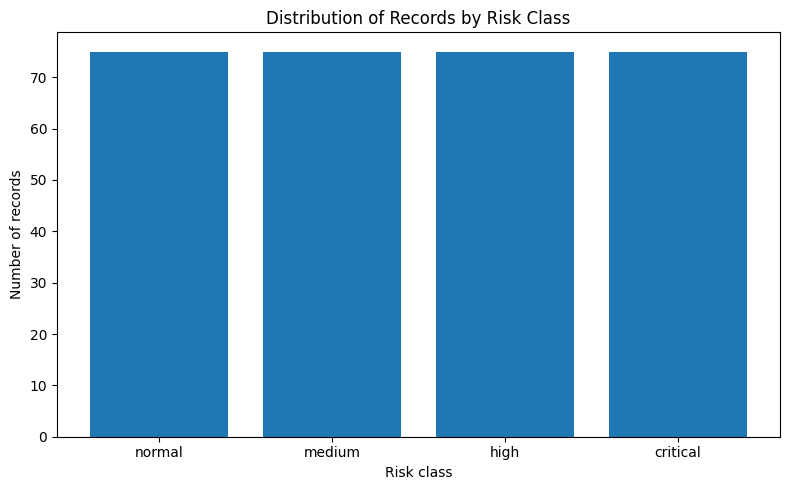

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/class_distribution.png


In [5]:
# Class distribution

class_counts = (
    processed_df["risk_level"]
    .value_counts()
    .reindex(RISK_ORDER)
    .fillna(0)
)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribution of Records by Risk Class")
plt.xlabel("Risk class")
plt.ylabel("Number of records")
plt.tight_layout()

class_distribution_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(class_distribution_path, dpi=150)
plt.show()

print("Figure saved at:", class_distribution_path)

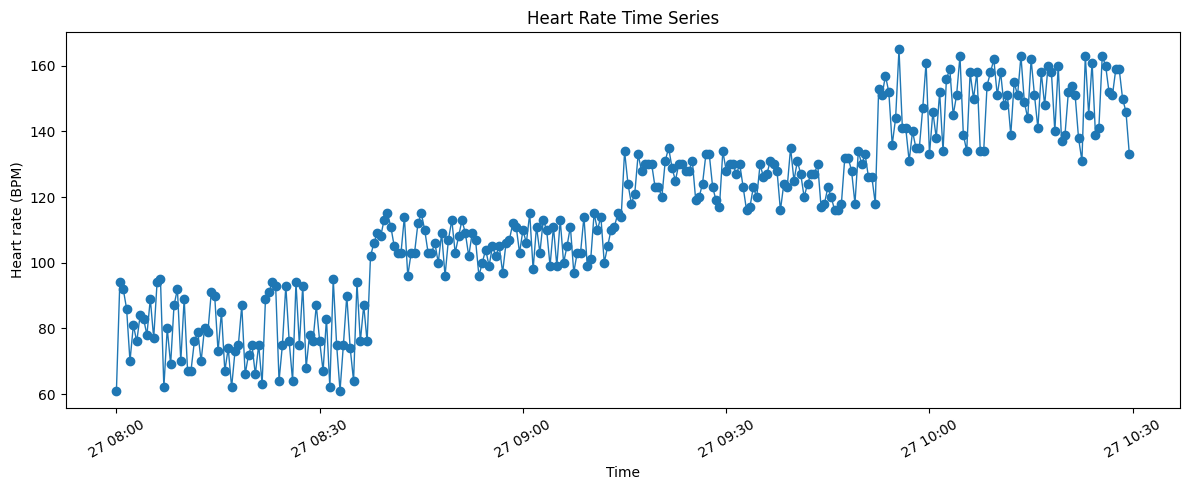

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/heart_rate_time_series.png


In [6]:
# Heart rate time series

plt.figure(figsize=(12, 5))
plt.plot(
    processed_df["timestamp"],
    processed_df["heart_rate"],
    marker="o",
    linewidth=1
)
plt.title("Heart Rate Time Series")
plt.xlabel("Time")
plt.ylabel("Heart rate (BPM)")
plt.xticks(rotation=30)
plt.tight_layout()

heart_rate_series_path = FIGURES_DIR / "heart_rate_time_series.png"
plt.savefig(heart_rate_series_path, dpi=150)
plt.show()

print("Figure saved at:", heart_rate_series_path)

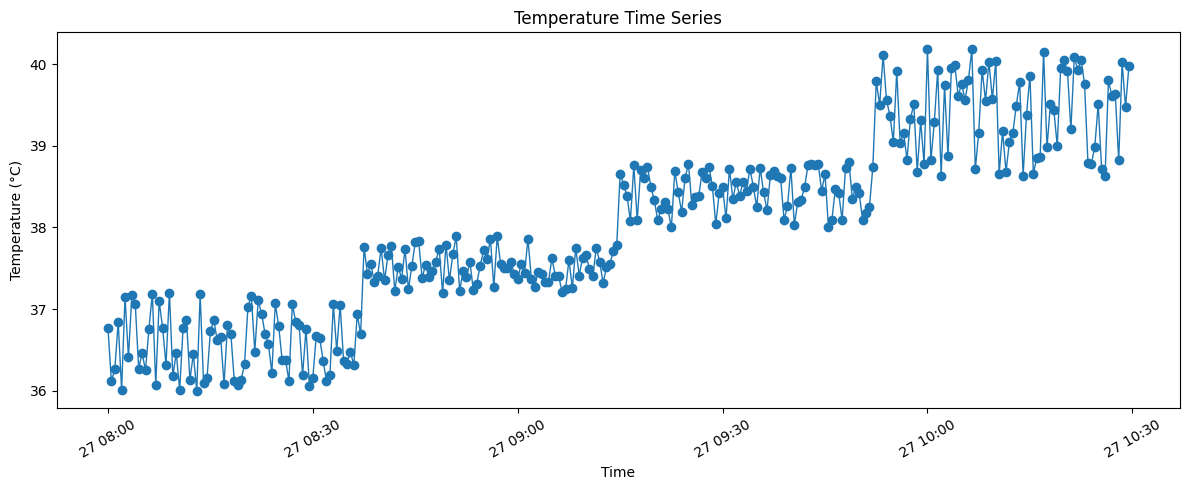

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/temperature_time_series.png


In [7]:
# Temperature time series

plt.figure(figsize=(12, 5))
plt.plot(
    processed_df["timestamp"],
    processed_df["temperature"],
    marker="o",
    linewidth=1
)
plt.title("Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=30)
plt.tight_layout()

temperature_series_path = FIGURES_DIR / "temperature_time_series.png"
plt.savefig(temperature_series_path, dpi=150)
plt.show()

print("Figure saved at:", temperature_series_path)

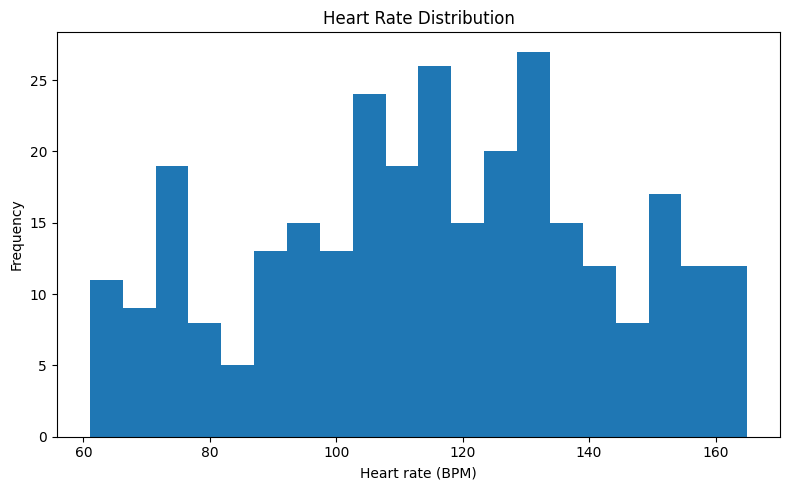

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/heart_rate_distribution.png


In [8]:
# Heart rate distribution

plt.figure(figsize=(8, 5))
plt.hist(processed_df["heart_rate"], bins=20)
plt.title("Heart Rate Distribution")
plt.xlabel("Heart rate (BPM)")
plt.ylabel("Frequency")
plt.tight_layout()

heart_rate_distribution_path = FIGURES_DIR / "heart_rate_distribution.png"
plt.savefig(heart_rate_distribution_path, dpi=150)
plt.show()

print("Figure saved at:", heart_rate_distribution_path)

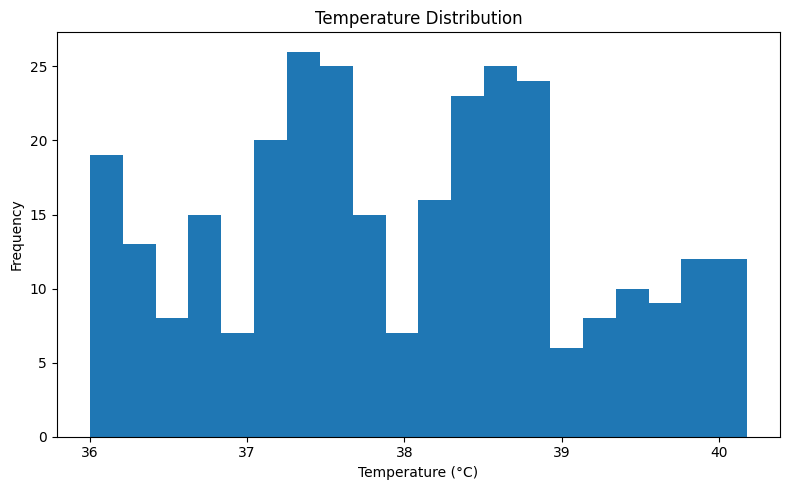

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/temperature_distribution.png


In [9]:
# Temperature distribution

plt.figure(figsize=(8, 5))
plt.hist(processed_df["temperature"], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.tight_layout()

temperature_distribution_path = FIGURES_DIR / "temperature_distribution.png"
plt.savefig(temperature_distribution_path, dpi=150)
plt.show()

print("Figure saved at:", temperature_distribution_path)

# **Time-Window Construction**

Because the activity focuses on health time series, the models should not classify only isolated records. Instead, the dataset is transformed into temporal windows.

A temporal window is a sequence of consecutive readings. For example, a window with size 10 represents 10 sequential measurements from the simulated wearable device.

From each window, statistical features are extracted, such as:

| Feature Type | Examples |
|---|---|
| Temperature features | Mean, standard deviation, minimum, maximum, slope |
| Heart rate features | Mean, standard deviation, minimum, maximum, slope |
| Movement features | Mean movement level, movement detection ratio, no-movement ratio |
| Emergency feature | Emergency button activation ratio |

This transformation allows the traditional model to analyze patterns over time instead of isolated values.

In [10]:
def calculate_slope(values: np.ndarray) -> float:
    """
    Calculates the linear slope of a numeric sequence.
    """

    values = np.asarray(values, dtype=float)

    if len(values) < 2:
        return 0.0

    x = np.arange(len(values))

    try:
        slope = np.polyfit(x, values, 1)[0]
    except Exception:
        slope = 0.0

    return float(slope)


def build_time_windows(
    dataframe: pd.DataFrame,
    window_size: int = 10,
    step_size: int = 3
) -> pd.DataFrame:
    """
    Builds time-window features from the processed dataset.
    """

    df = dataframe.copy().sort_values("timestamp").reset_index(drop=True)

    records = []

    signal_columns = [
        "temperature",
        "heart_rate",
        "movement_level"
    ]

    for start_idx in range(0, len(df) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        window = df.iloc[start_idx:end_idx].copy()

        record = {
            "window_start": window["timestamp"].iloc[0],
            "window_end": window["timestamp"].iloc[-1],
            "risk_level": window["risk_level"].iloc[-1]
        }

        for col in signal_columns:
            values = window[col].astype(float).values

            record[f"{col}_mean"] = float(np.mean(values))
            record[f"{col}_std"] = float(np.std(values))
            record[f"{col}_min"] = float(np.min(values))
            record[f"{col}_max"] = float(np.max(values))
            record[f"{col}_range"] = float(np.max(values) - np.min(values))
            record[f"{col}_slope"] = calculate_slope(values)
            record[f"{col}_first"] = float(values[0])
            record[f"{col}_last"] = float(values[-1])

            record[f"{col}_sequence"] = values.tolist()

        records.append(record)

    windows_df = pd.DataFrame(records)

    return windows_df


WINDOW_SIZE = 10
STEP_SIZE = 3

windows_df = build_time_windows(
    processed_df,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE
)

windows_dataset_path = PROCESSED_DIR / "cardioia_time_windows.csv"
windows_df.to_csv(windows_dataset_path, index=False)

print("Time-window dataset shape:", windows_df.shape)
print("Time-window dataset saved at:", windows_dataset_path)

display(windows_df.head())
display(windows_df["risk_level"].value_counts().reindex(RISK_ORDER))


Time-window dataset shape: (97, 30)
Time-window dataset saved at: /content/drive/MyDrive/go_beyond2/data/processed/cardioia_time_windows.csv


,window_start,window_end,risk_level,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_range,temperature_slope,temperature_first,...,heart_rate_sequence,movement_level_mean,movement_level_std,movement_level_min,movement_level_max,movement_level_range,movement_level_slope,movement_level_first,movement_level_last,movement_level_sequence
0,2026-04-27 08:00:00,2026-04-27 08:04:30,normal,36.606,0.420029,36.01,37.17,1.16,0.039273,36.77,...,"[61.0, 94.0, 92.0, 86.0, 70.0, 81.0, 76.0, 84....",0.795,0.128316,0.63,0.99,0.36,0.009758,0.90,0.99,"[0.9, 0.63, 0.84, 0.69, 0.88, 0.64, 0.92, 0.63..."
1,2026-04-27 08:01:30,2026-04-27 08:06:00,normal,36.638,0.392805,36.01,37.17,1.16,-0.018303,36.84,...,"[86.0, 70.0, 81.0, 76.0, 84.0, 83.0, 78.0, 89....",0.820,0.117218,0.63,0.99,0.36,0.019758,0.69,0.89,"[0.69, 0.88, 0.64, 0.92, 0.63, 0.83, 0.99, 0.8..."
2,2026-04-27 08:03:00,2026-04-27 08:07:30,normal,36.674,0.409077,36.07,37.19,1.12,0.002545,36.41,...,"[76.0, 84.0, 83.0, 78.0, 89.0, 77.0, 94.0, 95....",0.829,0.112911,0.63,0.99,0.36,-0.006121,0.92,0.69,"[0.92, 0.63, 0.83, 0.99, 0.85, 0.88, 0.89, 0.6..."
3,2026-04-27 08:04:30,2026-04-27 08:09:00,normal,36.639,0.400960,36.07,37.20,1.13,0.059939,36.27,...,"[78.0, 89.0, 77.0, 94.0, 95.0, 62.0, 80.0, 69....",0.838,0.105338,0.69,0.99,0.30,-0.013091,0.99,0.80,"[0.99, 0.85, 0.88, 0.89, 0.69, 0.92, 0.69, 0.7..."
4,2026-04-27 08:06:00,2026-04-27 08:10:30,normal,36.606,0.437680,36.01,37.20,1.19,-0.069455,36.76,...,"[94.0, 95.0, 62.0, 80.0, 69.0, 87.0, 92.0, 70....",0.826,0.096457,0.69,0.96,0.27,0.007515,0.89,0.87,"[0.89, 0.69, 0.92, 0.69, 0.71, 0.96, 0.8, 0.92..."


,count
risk_level,
normal,22
medium,25
high,25
critical,25


# **Train and Test Split**

The dataset is divided into training and testing subsets.

The training set is used to teach the models how to classify the risk levels. The testing set is used to evaluate the models with data that was not used during training.

A stratified split is applied to preserve the proportion of each risk class in both subsets. This is important because the model comparison must be fair and consistent across all classes.

In [11]:
# ============================================================
# 9. Feature Selection
# ============================================================

def get_model_feature_columns(dataframe: pd.DataFrame) -> list:
    """
    Selects numeric time-window features for model training.
    """

    excluded_terms = [
        "risk",
        "label",
        "target",
        "class",
        "window_start",
        "window_end",
        "timestamp",
        "time",
        "date",
        "emergency",
        "alert",
        "critical",
        "status",
        "sequence"
    ]

    selected_columns = []

    for col in dataframe.columns:
        col_lower = col.lower()

        if any(term in col_lower for term in excluded_terms):
            continue

        if pd.api.types.is_numeric_dtype(dataframe[col]):
            selected_columns.append(col)

    return selected_columns


feature_columns = get_model_feature_columns(windows_df)

print("Selected feature columns:")
for col in feature_columns:
    print("-", col)

if len(feature_columns) == 0:
    raise ValueError("No numeric feature columns were selected.")

Selected feature columns:
- temperature_mean
- temperature_std
- temperature_min
- temperature_max
- temperature_range
- temperature_slope
- temperature_first
- temperature_last
- heart_rate_mean
- heart_rate_std
- heart_rate_min
- heart_rate_max
- heart_rate_range
- heart_rate_slope
- heart_rate_first
- heart_rate_last
- movement_level_mean
- movement_level_std
- movement_level_min
- movement_level_max
- movement_level_range
- movement_level_slope
- movement_level_first
- movement_level_last


In [12]:
def classwise_temporal_split(
    dataframe: pd.DataFrame,
    target_column: str = "risk_level",
    train_ratio: float = 0.70,
    gap_size: int = 2
):
    """
    Performs a class-wise temporal split.

    This keeps all classes represented in both training and testing subsets
    while respecting the chronological order inside each class.
    """

    train_parts = []
    test_parts = []
    skipped_parts = []

    for class_name in RISK_ORDER:
        class_df = (
            dataframe[dataframe[target_column] == class_name]
            .sort_values("window_end")
            .reset_index(drop=True)
        )

        if len(class_df) == 0:
            continue

        split_idx = int(len(class_df) * train_ratio)

        train_end = max(0, split_idx - gap_size)
        test_start = min(len(class_df), split_idx + gap_size)

        train_part = class_df.iloc[:train_end].copy()
        skipped_part = class_df.iloc[train_end:test_start].copy()
        test_part = class_df.iloc[test_start:].copy()

        train_parts.append(train_part)
        skipped_parts.append(skipped_part)
        test_parts.append(test_part)

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)
    skipped_df = pd.concat(skipped_parts, ignore_index=True)

    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

    return train_df, test_df, skipped_df


train_df, test_df, skipped_df = classwise_temporal_split(
    windows_df,
    target_column="risk_level",
    train_ratio=0.70,
    gap_size=2
)

train_windows_path = PROCESSED_DIR / "train_time_windows.csv"
test_windows_path = PROCESSED_DIR / "test_time_windows.csv"
skipped_windows_path = PROCESSED_DIR / "skipped_gap_time_windows.csv"

train_df.to_csv(train_windows_path, index=False)
test_df.to_csv(test_windows_path, index=False)
skipped_df.to_csv(skipped_windows_path, index=False)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)
print("Skipped gap windows:", skipped_df.shape)

print("\nTraining class distribution:")
display(train_df["risk_level"].value_counts().reindex(RISK_ORDER))

print("\nTesting class distribution:")
display(test_df["risk_level"].value_counts().reindex(RISK_ORDER))

print("\nSaved files:")
print(train_windows_path)
print(test_windows_path)
print(skipped_windows_path)

Training set shape: (58, 30)
Testing set shape: (23, 30)
Skipped gap windows: (16, 30)

Training class distribution:


,count
risk_level,
normal,13
medium,15
high,15
critical,15



Testing class distribution:


,count
risk_level,
normal,5
medium,6
high,6
critical,6



Saved files:
/content/drive/MyDrive/go_beyond2/data/processed/train_time_windows.csv
/content/drive/MyDrive/go_beyond2/data/processed/test_time_windows.csv
/content/drive/MyDrive/go_beyond2/data/processed/skipped_gap_time_windows.csv


In [13]:
# ============================================================
# 11. Prepare Training and Testing Matrices
# ============================================================

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df["risk_level"].copy()
y_test = test_df["risk_level"].copy()

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

label_encoder = LabelEncoder()
label_encoder.fit(RISK_ORDER)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

class_names = list(label_encoder.classes_)

print("Classes:", class_names)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Classes: [np.str_('critical'), np.str_('high'), np.str_('medium'), np.str_('normal')]
X_train shape: (58, 24)
X_test shape: (23, 24)


# **Traditional Model — Logistic Regression**

Logistic Regression is used as the traditional machine learning classifier. Although it is a simple model, it is widely used as a baseline because it is fast, interpretable, and effective for classification problems.

In this experiment, Logistic Regression does not receive the raw time series directly. Instead, it receives statistical features extracted from each temporal window.

The model pipeline includes:

| Component | Function |
|---|---|
| StandardScaler | Normalizes the numerical features |
| LogisticRegression | Classifies each window into a risk level |

This model represents a practical approach for risk classification in low-complexity health monitoring systems.

In [15]:
# ============================================================
# 12. Evaluation Utility Functions
# ============================================================

def calculate_metrics(y_true, y_pred, model_name: str) -> dict:
    """
    Calculates weighted classification metrics.
    """

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }


def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    title: str,
    output_path: Path
):
    """
    Plots and saves a confusion matrix.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=30)
    plt.yticks(tick_marks, labels)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j,
                i,
                str(value),
                horizontalalignment="center",
                color="white" if value > threshold else "black"
            )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Figure saved at:", output_path)


def save_classification_report(
    y_true,
    y_pred,
    labels,
    model_name: str,
    output_path: Path
):
    """
    Saves a classification report as JSON.
    """

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=labels,
        output_dict=True,
        zero_division=0
    )

    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(report, file, indent=4)

    print(f"{model_name} classification report saved at:", output_path)

Classification Report — Logistic Regression
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00         6
        high       1.00      1.00      1.00         6
      medium       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         5

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

Logistic Regression classification report saved at: /content/drive/MyDrive/go_beyond2/outputs/metrics/logistic_regression_report.json


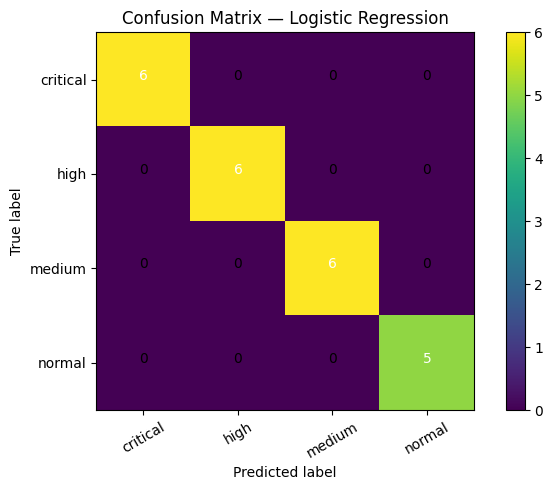

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/logistic_regression_confusion_matrix.png


In [16]:
# ============================================================
# 13. Traditional Model — Logistic Regression
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    penalty="l2",
    C=0.25,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_encoded)

logistic_predictions_encoded = logistic_model.predict(X_test_scaled)
logistic_predictions = label_encoder.inverse_transform(logistic_predictions_encoded)

print("Classification Report — Logistic Regression")
print(
    classification_report(
        y_test,
        logistic_predictions,
        labels=class_names,
        target_names=class_names,
        zero_division=0
    )
)

logistic_report_path = METRICS_DIR / "logistic_regression_report.json"

save_classification_report(
    y_test,
    logistic_predictions,
    class_names,
    "Logistic Regression",
    logistic_report_path
)

logistic_cm_path = FIGURES_DIR / "logistic_regression_confusion_matrix.png"

plot_confusion_matrix(
    y_test,
    logistic_predictions,
    class_names,
    "Confusion Matrix — Logistic Regression",
    logistic_cm_path
)

# **Neuromorphic Model — Leaky Integrate-and-Fire (LIF)**

The Leaky Integrate-and-Fire model is a simplified neuromorphic model inspired by biological neurons. It simulates a neuron that accumulates input over time, loses part of its accumulated voltage, and fires a spike when its membrane potential reaches a threshold.

In this experiment, the LIF model receives temporal signals from the CardioIA dataset. The input current is calculated from:

| Signal | Role in LIF Input |
|---|---|
| Heart rate | Main physiological stimulus |
| Temperature | Secondary physiological stimulus |
| Low movement | Indicates possible inactivity or risk |
| Emergency button | Reinforces critical event detection |

The LIF model transforms the temporal behavior of the signals into spike-based features, such as spike count, firing rate, maximum voltage, and mean input current.

In [17]:
class LIFSpikeClassifier:
    """
    Simplified Leaky Integrate-and-Fire classifier.

    The model transforms each time window into spike-based features and then
    classifies samples using nearest class prototypes.
    """

    def __init__(
        self,
        threshold: float = 1.0,
        resistance: float = 1.0,
        tau: float = 2.0,
        reset_voltage: float = 0.0,
        dt: float = 1.0
    ):
        self.threshold = threshold
        self.resistance = resistance
        self.tau = tau
        self.reset_voltage = reset_voltage
        self.dt = dt

        self.scaler = StandardScaler()
        self.class_prototypes = {}
        self.classes_ = None

    def normalize_sequence(self, values, min_value, max_value):
        """
        Normalizes a numeric sequence to the range [0, 1].
        """

        values = np.asarray(values, dtype=float)

        if max_value == min_value:
            return np.zeros_like(values)

        values = (values - min_value) / (max_value - min_value)
        values = np.clip(values, 0, 1)

        return values

    def sequence_to_current(
        self,
        heart_rate_sequence,
        temperature_sequence,
        movement_sequence
    ):
        """
        Converts physiological signals into input current.
        """

        heart_rate_norm = self.normalize_sequence(
            heart_rate_sequence,
            min_value=40,
            max_value=200
        )

        temperature_norm = self.normalize_sequence(
            temperature_sequence,
            min_value=35,
            max_value=42
        )

        movement_norm = self.normalize_sequence(
            movement_sequence,
            min_value=0,
            max_value=1
        )

        input_current = (
            0.45 * heart_rate_norm +
            0.35 * temperature_norm +
            0.20 * (1 - movement_norm)
        )

        return input_current

    def simulate_lif(self, input_current):
        """
        Simulates membrane voltage and spike generation.
        """

        voltage = 0.0
        spikes = []
        voltages = []

        for current in input_current:
            dv = (
                -voltage +
                self.resistance * current
            ) / self.tau

            voltage += dv * self.dt

            if voltage >= self.threshold:
                spikes.append(1)
                voltage = self.reset_voltage
            else:
                spikes.append(0)

            voltages.append(voltage)

        return np.array(spikes), np.array(voltages)

    def extract_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Extracts LIF spike-based features from time-window sequences.
        """

        feature_rows = []

        for _, row in dataframe.iterrows():
            heart_rate_sequence = row["heart_rate_sequence"]
            temperature_sequence = row["temperature_sequence"]
            movement_sequence = row["movement_level_sequence"]

            input_current = self.sequence_to_current(
                heart_rate_sequence,
                temperature_sequence,
                movement_sequence
            )

            spikes, voltages = self.simulate_lif(input_current)

            feature_rows.append({
                "spike_count": float(np.sum(spikes)),
                "spike_rate": float(np.mean(spikes)),
                "mean_voltage": float(np.mean(voltages)),
                "max_voltage": float(np.max(voltages)),
                "final_voltage": float(voltages[-1]),
                "mean_current": float(np.mean(input_current)),
                "max_current": float(np.max(input_current)),
                "current_slope": calculate_slope(input_current)
            })

        return pd.DataFrame(feature_rows)

    def fit(self, dataframe: pd.DataFrame, labels: pd.Series):
        """
        Fits class prototypes from LIF features.
        """

        lif_features = self.extract_features(dataframe)
        lif_features_scaled = self.scaler.fit_transform(lif_features)

        labels = pd.Series(labels).reset_index(drop=True)

        self.classes_ = sorted(
            labels.unique().tolist(),
            key=lambda x: RISK_ORDER.index(x)
        )

        self.class_prototypes = {}

        for class_name in self.classes_:
            class_indexes = labels[labels == class_name].index
            class_vectors = lif_features_scaled[class_indexes]
            self.class_prototypes[class_name] = np.mean(class_vectors, axis=0)

        return self

    def predict(self, dataframe: pd.DataFrame):
        """
        Predicts labels using the nearest class prototype.
        """

        lif_features = self.extract_features(dataframe)
        lif_features_scaled = self.scaler.transform(lif_features)

        predictions = []

        for vector in lif_features_scaled:
            distances = {}

            for class_name, prototype in self.class_prototypes.items():
                distance = np.linalg.norm(vector - prototype)
                distances[class_name] = distance

            predicted_class = min(distances, key=distances.get)
            predictions.append(predicted_class)

        return np.array(predictions)

    def transform_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        """
        Returns LIF features for inspection and export.
        """

        return self.extract_features(dataframe)

# **LIF Signal Interpretation**

The following plots show how the LIF neuron reacts to a selected time window.

| Plot | Meaning |
|---|---|
| Input current | Represents the combined stimulus generated from health signals |
| Membrane voltage | Shows how the neuron accumulates and leaks potential over time |
| Spike train | Indicates when the neuron fired due to high accumulated stimulus |

In critical windows, higher heart rate, increased temperature, low movement, and emergency activation tend to increase the input current and may produce more spikes.

Classification Report — LIF Spike Classifier
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00         6
        high       1.00      1.00      1.00         6
      medium       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         5

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

LIF Spike Classifier classification report saved at: /content/drive/MyDrive/go_beyond2/outputs/metrics/lif_spike_classifier_report.json


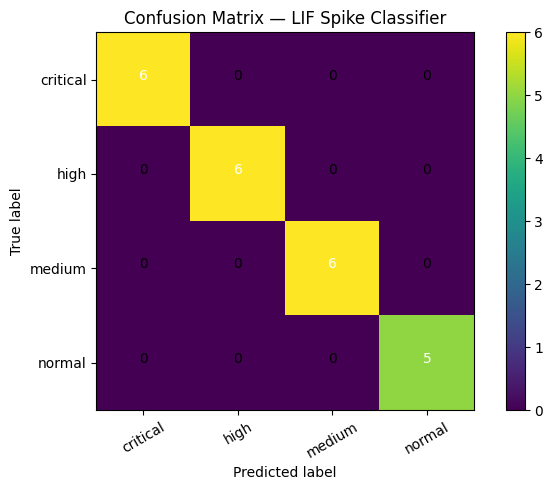

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/lif_spike_classifier_confusion_matrix.png


In [18]:
lif_model = LIFSpikeClassifier(
    threshold=1.0,
    resistance=1.0,
    tau=2.0,
    reset_voltage=0.0,
    dt=1.0
)

lif_model.fit(train_df, y_train)

lif_predictions = lif_model.predict(test_df)

print("Classification Report — LIF Spike Classifier")
print(
    classification_report(
        y_test,
        lif_predictions,
        labels=class_names,
        target_names=class_names,
        zero_division=0
    )
)

lif_report_path = METRICS_DIR / "lif_spike_classifier_report.json"
save_classification_report(
    y_test,
    lif_predictions,
    class_names,
    "LIF Spike Classifier",
    lif_report_path
)

lif_cm_path = FIGURES_DIR / "lif_spike_classifier_confusion_matrix.png"
plot_confusion_matrix(
    y_test,
    lif_predictions,
    class_names,
    "Confusion Matrix — LIF Spike Classifier",
    lif_cm_path
)

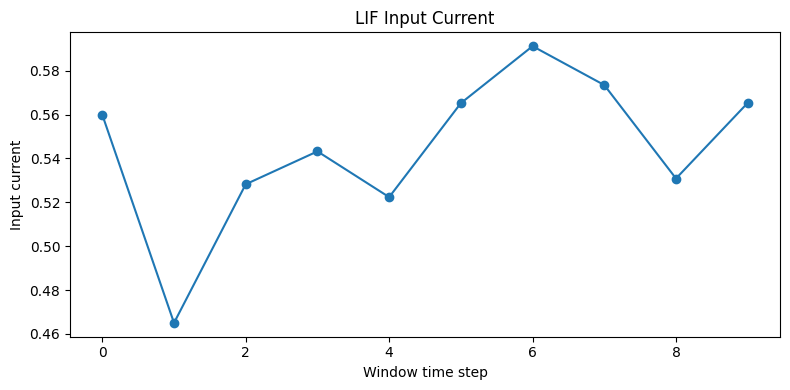

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/lif_input_current.png


In [19]:
sample_index = 0

sample_window = test_df.iloc[[sample_index]].copy()

sample_current = lif_model.sequence_to_current(
    sample_window.iloc[0]["heart_rate_sequence"],
    sample_window.iloc[0]["temperature_sequence"],
    sample_window.iloc[0]["movement_level_sequence"]
)

sample_spikes, sample_voltages = lif_model.simulate_lif(sample_current)

plt.figure(figsize=(8, 4))
plt.plot(sample_current, marker="o")
plt.title("LIF Input Current")
plt.xlabel("Window time step")
plt.ylabel("Input current")
plt.tight_layout()

lif_current_path = FIGURES_DIR / "lif_input_current.png"
plt.savefig(lif_current_path, dpi=150)
plt.show()

print("Figure saved at:", lif_current_path)

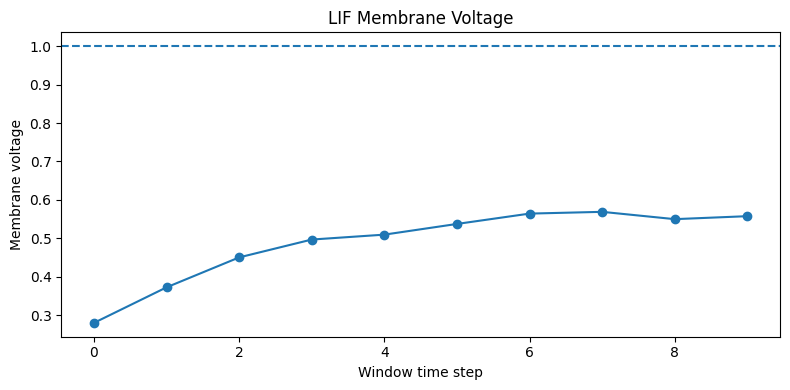

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/lif_membrane_voltage.png


In [20]:
plt.figure(figsize=(8, 4))
plt.plot(sample_voltages, marker="o")
plt.axhline(y=lif_model.threshold, linestyle="--")
plt.title("LIF Membrane Voltage")
plt.xlabel("Window time step")
plt.ylabel("Membrane voltage")
plt.tight_layout()

lif_voltage_path = FIGURES_DIR / "lif_membrane_voltage.png"
plt.savefig(lif_voltage_path, dpi=150)
plt.show()

print("Figure saved at:", lif_voltage_path)

# P**erformance Metrics**

The models are evaluated using standard classification metrics.

| Metric | Meaning |
|---|---|
| Accuracy | Proportion of correctly classified samples |
| Precision | How many predicted positive cases were actually correct |
| Recall | How many real positive cases were correctly detected |
| F1-score | Harmonic mean between precision and recall |

Since this is a multi-class classification problem, weighted averages are used to account for all risk classes.

In [21]:
metrics = []

metrics.append(
    calculate_metrics(
        y_test,
        logistic_predictions,
        "Logistic Regression"
    )
)

metrics.append(
    calculate_metrics(
        y_test,
        lif_predictions,
        "LIF Spike Classifier"
    )
)

metrics_df = pd.DataFrame(metrics)

metrics_output_path = METRICS_DIR / "model_comparison_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)

print("Model comparison metrics saved at:", metrics_output_path)

display(metrics_df)

Model comparison metrics saved at: /content/drive/MyDrive/go_beyond2/outputs/metrics/model_comparison_metrics.csv


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,1.0,1.0,1.0,1.0
1,LIF Spike Classifier,1.0,1.0,1.0,1.0


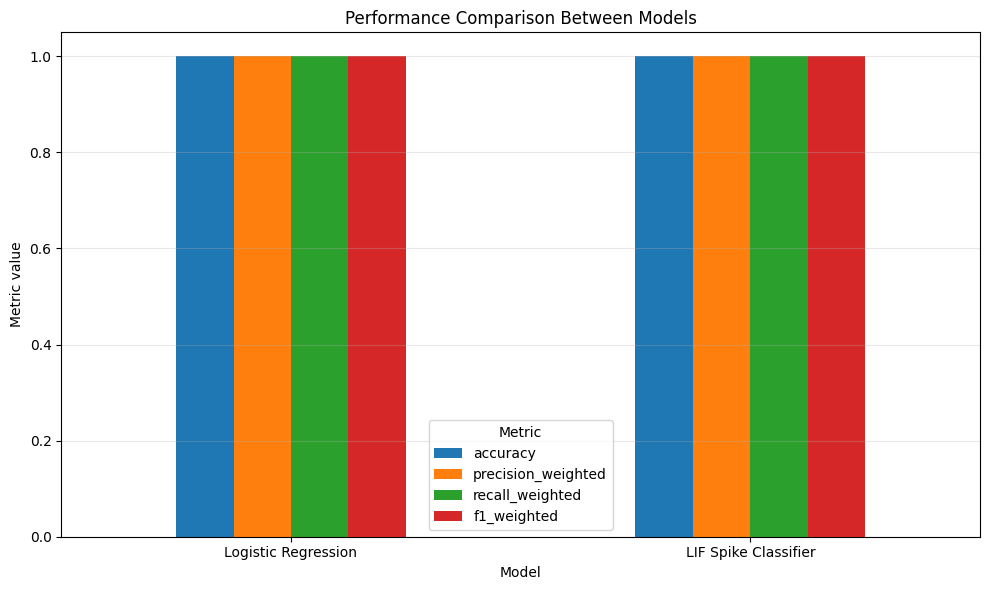

Figure saved at: /content/drive/MyDrive/go_beyond2/outputs/figures/model_performance_comparison.png


In [22]:
# Model comparison plot

plot_metrics = [
    "accuracy",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

plot_df = metrics_df.set_index("model")[plot_metrics]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Performance Comparison Between Models")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

comparison_plot_path = FIGURES_DIR / "model_performance_comparison.png"
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

print("Figure saved at:", comparison_plot_path)

In [23]:
# ============================================================
# 17. Save Predictions
# ============================================================

comparison_predictions = test_df[
    [
        "window_start",
        "window_end",
        "risk_level"
    ]
].copy()

comparison_predictions["logistic_regression_prediction"] = logistic_predictions
comparison_predictions["lif_spike_classifier_prediction"] = lif_predictions

comparison_predictions_path = PREDICTIONS_DIR / "model_predictions.csv"
comparison_predictions.to_csv(comparison_predictions_path, index=False)

print("Predictions saved at:", comparison_predictions_path)

display(comparison_predictions.head(20))

Predictions saved at: /content/drive/MyDrive/go_beyond2/outputs/predictions/model_predictions.csv


,window_start,window_end,risk_level,logistic_regression_prediction,lif_spike_classifier_prediction
0,2026-04-27 09:45:00,2026-04-27 09:49:30,high,high,high
1,2026-04-27 09:07:30,2026-04-27 09:12:00,medium,medium,medium
2,2026-04-27 08:25:30,2026-04-27 08:30:00,normal,normal,normal
3,2026-04-27 09:06:00,2026-04-27 09:10:30,medium,medium,medium
4,2026-04-27 10:16:30,2026-04-27 10:21:00,critical,critical,critical
5,2026-04-27 09:40:30,2026-04-27 09:45:00,high,high,high
6,2026-04-27 08:27:00,2026-04-27 08:31:30,normal,normal,normal
7,2026-04-27 09:42:00,2026-04-27 09:46:30,high,high,high
8,2026-04-27 09:01:30,2026-04-27 09:06:00,medium,medium,medium
9,2026-04-27 08:28:30,2026-04-27 08:33:00,normal,normal,normal


In [24]:
# ============================================================
# 18. Save LIF Extracted Features
# ============================================================

lif_train_features = lif_model.transform_features(train_df)
lif_test_features = lif_model.transform_features(test_df)

lif_train_features["risk_level"] = y_train.reset_index(drop=True)
lif_test_features["risk_level"] = y_test.reset_index(drop=True)

lif_train_features_path = PROCESSED_DIR / "lif_train_features.csv"
lif_test_features_path = PROCESSED_DIR / "lif_test_features.csv"

lif_train_features.to_csv(lif_train_features_path, index=False)
lif_test_features.to_csv(lif_test_features_path, index=False)

print("LIF training features saved at:", lif_train_features_path)
print("LIF testing features saved at:", lif_test_features_path)

display(lif_test_features.head())

LIF training features saved at: /content/drive/MyDrive/go_beyond2/data/processed/lif_train_features.csv
LIF testing features saved at: /content/drive/MyDrive/go_beyond2/data/processed/lif_test_features.csv


,spike_count,spike_rate,mean_voltage,max_voltage,final_voltage,mean_current,max_current,current_slope,risk_level
0,0.0,0.0,0.488743,0.568918,0.557636,0.544506,0.591250,0.005595,high
1,0.0,0.0,0.360380,0.423693,0.389705,0.399350,0.440875,0.000736,medium
2,0.0,0.0,0.213770,0.277477,0.220234,0.235794,0.321063,-0.003011,normal
3,0.0,0.0,0.354769,0.409308,0.409308,0.395700,0.431688,0.001413,medium
4,0.0,0.0,0.638668,0.710262,0.700444,0.708712,0.739375,-0.002608,critical


# **Final Comparative Analysis**

The experiment compared a traditional machine learning model and a simple neuromorphic model for classifying synthetic health time-series data.

Logistic Regression showed the advantage of being simple, fast, and easy to interpret. It performed classification based on statistical features extracted from temporal windows, such as mean heart rate, maximum temperature, movement ratio, and emergency activation ratio.

The LIF model introduced a neuromorphic perspective by converting physiological signals into input currents and spike-based features. This approach is useful for demonstrating how temporal events can be represented through neuron-inspired dynamics.

| Model | Main Strength | Main Limitation |
|---|---|---|
| Logistic Regression | Simple, fast and interpretable | Depends on manual feature extraction |
| LIF Spike Classifier | Represents temporal behavior through spikes | Sensitive to parameters and encoding strategy |

In this prototype, both models are valid for academic demonstration. However, the results should not be interpreted as clinical evidence because the dataset is synthetic and limited. The main contribution of the experiment is to compare two different approaches for health time-series classification and discuss their advantages, limitations, and possible applications.

In [25]:
best_model_row = metrics_df.sort_values(
    "f1_weighted",
    ascending=False
).iloc[0]

analysis_text = f"""
# Final Comparative Analysis

This experiment compared two approaches for classifying synthetic health
time-series data from the CardioIA project.

## Models Evaluated

1. Logistic Regression
2. LIF Spike Classifier

## Best Model

The best model based on weighted F1-score was:

**{best_model_row["model"]}**

Weighted F1-score: {best_model_row["f1_weighted"]:.4f}

## Output Files

The experiment generated the following output groups:

- Processed datasets in `data/processed/`
- Figures in `outputs/figures/`
- Metrics in `outputs/metrics/`
- Predictions in `outputs/predictions/`

## Interpretation

Logistic Regression is more practical and easier to interpret for structured
tabular features.

The LIF Spike Classifier is useful for demonstrating neuromorphic-inspired
processing applied to health time-series windows.

Both approaches can support academic analysis of wearable health monitoring
systems using synthetic data.
"""

analysis_report_path = METRICS_DIR / "english_comparative_analysis.md"

with open(analysis_report_path, "w", encoding="utf-8") as file:
    file.write(analysis_text)

print("Comparative analysis report saved at:", analysis_report_path)
print(analysis_text)

Comparative analysis report saved at: /content/drive/MyDrive/go_beyond2/outputs/metrics/english_comparative_analysis.md

# Final Comparative Analysis

This experiment compared two approaches for classifying synthetic health
time-series data from the CardioIA project.

## Models Evaluated

1. Logistic Regression
2. LIF Spike Classifier

## Best Model

The best model based on weighted F1-score was:

**Logistic Regression**

Weighted F1-score: 1.0000

## Output Files

The experiment generated the following output groups:

- Processed datasets in `data/processed/`
- Figures in `outputs/figures/`
- Metrics in `outputs/metrics/`
- Predictions in `outputs/predictions/`

## Interpretation

Logistic Regression is more practical and easier to interpret for structured
tabular features.

The LIF Spike Classifier is useful for demonstrating neuromorphic-inspired
processing applied to health time-series windows.

Both approaches can support academic analysis of wearable health monitoring
systems usi

In [26]:
# ============================================================
# 20. Final Output Summary
# ============================================================

print("Pipeline completed successfully.")
print()
print("Generated files:")
print("- Processed records:", processed_dataset_path)
print("- Time-window dataset:", windows_dataset_path)
print("- Training windows:", train_windows_path)
print("- Testing windows:", test_windows_path)
print("- Skipped gap windows:", skipped_windows_path)
print("- Logistic Regression report:", logistic_report_path)
print("- LIF Spike Classifier report:", lif_report_path)
print("- Model comparison metrics:", metrics_output_path)
print("- Model predictions:", comparison_predictions_path)
print("- LIF training features:", lif_train_features_path)
print("- LIF testing features:", lif_test_features_path)
print("- Comparative analysis report:", analysis_report_path)
print()
print("Google Drive project folder:")
print(PROJECT_ROOT)

Pipeline completed successfully.

Generated files:
- Processed records: /content/drive/MyDrive/go_beyond2/data/processed/cardioia_processed_records.csv
- Time-window dataset: /content/drive/MyDrive/go_beyond2/data/processed/cardioia_time_windows.csv
- Training windows: /content/drive/MyDrive/go_beyond2/data/processed/train_time_windows.csv
- Testing windows: /content/drive/MyDrive/go_beyond2/data/processed/test_time_windows.csv
- Skipped gap windows: /content/drive/MyDrive/go_beyond2/data/processed/skipped_gap_time_windows.csv
- Logistic Regression report: /content/drive/MyDrive/go_beyond2/outputs/metrics/logistic_regression_report.json
- LIF Spike Classifier report: /content/drive/MyDrive/go_beyond2/outputs/metrics/lif_spike_classifier_report.json
- Model comparison metrics: /content/drive/MyDrive/go_beyond2/outputs/metrics/model_comparison_metrics.csv
- Model predictions: /content/drive/MyDrive/go_beyond2/outputs/predictions/model_predictions.csv
- LIF training features: /content/dri